In [1]:
import os
import io
import random
import warnings
import collections
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageChops, ImageFilter
from scipy import ndimage
from scipy.stats import entropy, kurtosis, skew
from scipy.fft import dctn

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

ROOT = Path(r"C:\Users\Windows\Documents\CASIA2")
AU_DIR = ROOT / 'Au'
TP_DIR = ROOT / 'Tp'
EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

In [2]:
def get_tp_label(path: Path):
    """
    CASIA2 filename convention: Tp_<type>_<src>_<dst>_...
    If src == dst token it is copy-move (within same image family), else splicing.
    Returns 1 for copy-move, 2 for splicing.
    """
    parts = path.stem.split('_')
    try:
        return 1 if parts[-3] == parts[-2] else 2
    except Exception:
        return 2

In [3]:
def is_lossless(path: Path) -> bool:
    """
    Returns True if the file is stored losslessly (TIFF, BMP, PNG).
    ELA is unreliable on lossless images, so we skip it for these.
    """
    suffix = path.suffix.lower()
    if suffix in {'.tif', '.tiff', '.bmp', '.png'}:
        return True
    # Double-check by reading the PIL format
    try:
        with Image.open(path) as img:
            fmt = (img.format or '').upper()
            return fmt in {'TIFF', 'BMP', 'PNG'}
    except Exception:
        return suffix not in {'.jpg', '.jpeg'}

In [4]:
def load_image_rgb(path, resize_max=512):
    """Load image as uint8 RGB numpy array, resize if needed."""
    try:
        img = Image.open(path).convert('RGB')
    except Exception:
        return None
    w, h = img.size
    if max(h, w) > resize_max:
        scale = resize_max / max(h, w)
        img = img.resize((max(1, int(w * scale)), max(1, int(h * scale))), Image.LANCZOS)
    return np.array(img, dtype=np.uint8)


def load_grayscale(path, resize_max=512):
    rgb = load_image_rgb(path, resize_max)
    if rgb is None:
        return None
    return cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

In [5]:
def akaze_copymove_features(path, min_dist_px=20, ratio_thresh=0.90, resize_max=512):
    """
    Detects self-repetition within the image using AKAZE keypoint matching.
    Strong signal for copy-move; near-zero for authentic and spliced images.
    """
    img = load_grayscale(path, resize_max)
    if img is None:
        return _zero_cm_features()

    akaze = cv2.AKAZE_create(threshold=0.00035)
    kps, descs = akaze.detectAndCompute(img, None)
    if descs is None or len(kps) < 10:
        return _zero_cm_features()

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    raw = bf.knnMatch(descs, descs, k=4)

    candidates = []
    for trip in raw:
        non_self = [m for m in trip if m.queryIdx != m.trainIdx]
        if len(non_self) < 2:
            continue
        m, n = non_self[0], non_self[1]
        if m.distance <= ratio_thresh * n.distance:
            pt1 = np.array(kps[m.queryIdx].pt, dtype=np.float32)
            pt2 = np.array(kps[m.trainIdx].pt, dtype=np.float32)
            disp = pt2 - pt1
            if np.linalg.norm(disp) > min_dist_px:
                candidates.append((pt1, pt2, disp))

    if len(candidates) < 8:
        return _zero_cm_features()

    displacements = np.array([c[2] for c in candidates], dtype=np.float32)
    quantized = np.round(displacements / 4.0).astype(np.int16)
    keys, counts = np.unique(quantized, axis=0, return_counts=True)
    best_key = keys[np.argmax(counts)]
    mask = np.all(quantized == best_key, axis=1)
    inliers = [c for c, keep in zip(candidates, mask) if keep]

    n_inliers = len(inliers)
    inlier_ratio = n_inliers / max(len(candidates), 1)

    if n_inliers == 0:
        return _zero_cm_features()

    disps = np.array([c[2] for c in inliers], dtype=np.float32)
    lengths = np.linalg.norm(disps, axis=1)
    angles = np.arctan2(disps[:, 1], disps[:, 0])
    pts = np.array([c[0] for c in inliers], dtype=np.float32)
    centroid = pts.mean(axis=0)
    cluster_compactness = float(np.mean(np.linalg.norm(pts - centroid, axis=1)))
    cm_score = float((1 - np.exp(-n_inliers / 12.0)) * (0.5 + 0.5 * inlier_ratio))

    return {
        'cm_score': cm_score,
        'n_inliers': float(n_inliers),
        'inlier_ratio': float(inlier_ratio),
        'disp_mean': float(lengths.mean()),
        'disp_std': float(lengths.std()),
        'angle_std': float(angles.std()),
        'cluster_compactness': cluster_compactness,
    }


def _zero_cm_features():
    return {k: 0.0 for k in ['cm_score', 'n_inliers', 'inlier_ratio',
                               'disp_mean', 'disp_std', 'angle_std', 'cluster_compactness']}

In [6]:
def ela_features(path, quality=92, block_size=32):
    """
    Error Level Analysis: re-compress at known quality and measure residual.
    Only meaningful for JPEG images. Returns zeros for lossless formats.
    """
    if is_lossless(path):
        return _zero_ela_features()

    try:
        img_pil = Image.open(path).convert('RGB')
    except Exception:
        return _zero_ela_features()

    buf = io.BytesIO()
    img_pil.save(buf, 'JPEG', quality=quality)
    buf.seek(0)
    ela_arr = np.array(
        ImageChops.difference(img_pil, Image.open(buf).convert('RGB')),
        dtype=np.float32
    ).mean(axis=2)

    ela_mean = float(ela_arr.mean())
    ela_std = float(ela_arr.std())

    h, w = ela_arr.shape
    bs = max(8, min(block_size, min(h, w) // 8))
    block_means = []
    for r in range(0, h - bs + 1, bs):
        for c in range(0, w - bs + 1, bs):
            block_means.append(ela_arr[r:r + bs, c:c + bs].mean())
    block_means = np.array(block_means) if block_means else np.array([0.0])
    block_std = float(block_means.std())

    p95 = float(np.percentile(ela_arr, 95))
    hist, _ = np.histogram(ela_arr, bins=32, density=True)
    ela_entropy = float(entropy(hist + 1e-8))
    lvar = (ndimage.uniform_filter(ela_arr ** 2, size=bs)
            - ndimage.uniform_filter(ela_arr, size=bs) ** 2)
    lvar_max = float(lvar.max())

    # Spatial variance of ELA across image quadrants — spliced images often show
    # one quadrant with very different ELA than the rest.
    h2, w2 = h // 2, w // 2
    quads = [
        ela_arr[:h2, :w2], ela_arr[:h2, w2:],
        ela_arr[h2:, :w2], ela_arr[h2:, w2:]
    ]
    quad_means = np.array([q.mean() for q in quads])
    ela_quad_var = float(quad_means.var())

    return {
        'ela_mean': ela_mean, 'ela_std': ela_std, 'block_std': block_std,
        'ela_p95': p95, 'ela_entropy': ela_entropy, 'lvar_max': lvar_max,
        'ela_quad_var': ela_quad_var,
    }


def _zero_ela_features():
    return {k: 0.0 for k in ['ela_mean', 'ela_std', 'block_std',
                               'ela_p95', 'ela_entropy', 'lvar_max', 'ela_quad_var']}

In [7]:
def noise_inconsistency_features(path, resize_max=512, n_blocks=16):
    """
    Estimates local noise level across image blocks and measures its spatial
    variance. A spliced image typically has one region with a different
    noise fingerprint from the rest (different camera sensor).

    This is the key discriminator between copy-move and splicing:
    - Copy-move:  same camera, same noise profile everywhere → low variance
    - Splicing:   two cameras, different noise levels in pasted region → high variance
    - Authentic:  uniform noise from one camera → low variance
    """
    rgb = load_image_rgb(path, resize_max)
    if rgb is None:
        return _zero_noise_features()

    # High-pass filter to extract noise residual (Laplacian-based)
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    noise_map = gray - blurred  # Wiener-like noise residual

    h, w = noise_map.shape
    bh, bw = max(1, h // n_blocks), max(1, w // n_blocks)

    block_noise_stds = []
    for r in range(0, h - bh + 1, bh):
        for c in range(0, w - bw + 1, bw):
            block = noise_map[r:r + bh, c:c + bw]
            block_noise_stds.append(float(block.std()))

    block_noise_stds = np.array(block_noise_stds)
    if len(block_noise_stds) == 0:
        return _zero_noise_features()

    noise_std_mean = float(block_noise_stds.mean())
    noise_std_var = float(block_noise_stds.var())
    noise_std_max = float(block_noise_stds.max())
    # Coefficient of variation: relative spread — high → inconsistent noise → splicing
    noise_cv = float(block_noise_stds.std() / (block_noise_stds.mean() + 1e-8))
    # Skewness: one outlier block (pasted region) creates skewed distribution
    noise_skew = float(skew(block_noise_stds)) if len(block_noise_stds) > 2 else 0.0
    noise_kurt = float(kurtosis(block_noise_stds)) if len(block_noise_stds) > 3 else 0.0

    # Chrominance noise inconsistency: spliced regions often have different
    # chroma noise (e.g., different white balance or camera pipeline)
    ycrcb = cv2.cvtColor(rgb, cv2.COLOR_RGB2YCrCb).astype(np.float32)
    cr_noise = ycrcb[:, :, 1] - cv2.GaussianBlur(ycrcb[:, :, 1], (3, 3), 0)
    cb_noise = ycrcb[:, :, 2] - cv2.GaussianBlur(ycrcb[:, :, 2], (3, 3), 0)

    cr_block_stds, cb_block_stds = [], []
    for r in range(0, h - bh + 1, bh):
        for c in range(0, w - bw + 1, bw):
            cr_block_stds.append(cr_noise[r:r + bh, c:c + bw].std())
            cb_block_stds.append(cb_noise[r:r + bh, c:c + bw].std())

    chroma_noise_cv = float(np.std(cr_block_stds) / (np.mean(cr_block_stds) + 1e-8)
                            + np.std(cb_block_stds) / (np.mean(cb_block_stds) + 1e-8))

    return {
        'noise_std_mean': noise_std_mean,
        'noise_std_var': noise_std_var,
        'noise_std_max': noise_std_max,
        'noise_cv': noise_cv,
        'noise_skew': noise_skew,
        'noise_kurt': noise_kurt,
        'chroma_noise_cv': chroma_noise_cv,
    }


def _zero_noise_features():
    return {k: 0.0 for k in ['noise_std_mean', 'noise_std_var', 'noise_std_max',
                               'noise_cv', 'noise_skew', 'noise_kurt', 'chroma_noise_cv']}

In [8]:
def dct_blocking_features(path, resize_max=512):
    """
    Measures DCT blocking artifact consistency across the image.

    JPEG compression leaves 8x8 block boundaries. When an image region is
    taken from a *different* JPEG (splicing), its block grid may be offset
    or have a different quantization level → measurable boundary discontinuity.

    For copy-move: same block grid → low boundary variance.
    For splicing: misaligned block grid in pasted region → high boundary variance.
    For lossless: no blocking artifacts, but we still measure edge statistics.
    """
    gray = load_grayscale(path, resize_max)
    if gray is None:
        return _zero_dct_features()

    h, w = gray.shape
    gray_f = gray.astype(np.float32)

    # Horizontal and vertical boundary gradients at 8-pixel intervals
    h_edges, v_edges = [], []
    for r in range(8, h, 8):
        if r < h:
            diff = float(np.abs(gray_f[r, :] - gray_f[r - 1, :]).mean())
            h_edges.append(diff)
    for c in range(8, w, 8):
        if c < w:
            diff = float(np.abs(gray_f[:, c] - gray_f[:, c - 1]).mean())
            v_edges.append(diff)

    # Interior gradients (non-boundary)
    interior_h = float(np.abs(np.diff(gray_f, axis=0)).mean())
    interior_v = float(np.abs(np.diff(gray_f, axis=1)).mean())

    h_arr = np.array(h_edges) if h_edges else np.array([0.0])
    v_arr = np.array(v_edges) if v_edges else np.array([0.0])

    # Blocking score: ratio of boundary to interior gradients
    # High value = strong blocking artifacts (heavily compressed JPEG)
    blocking_h = float(h_arr.mean() / (interior_h + 1e-8))
    blocking_v = float(v_arr.mean() / (interior_v + 1e-8))

    # Variance of boundary gradients — spliced region creates outlier boundary strengths
    boundary_var_h = float(h_arr.var())
    boundary_var_v = float(v_arr.var())
    boundary_cv = float((h_arr.std() + v_arr.std()) / (h_arr.mean() + v_arr.mean() + 1e-8))

    return {
        'blocking_h': blocking_h,
        'blocking_v': blocking_v,
        'boundary_var_h': boundary_var_h,
        'boundary_var_v': boundary_var_v,
        'boundary_cv': boundary_cv,
    }


def _zero_dct_features():
    return {k: 0.0 for k in ['blocking_h', 'blocking_v',
                               'boundary_var_h', 'boundary_var_v', 'boundary_cv']}

In [9]:
def illumination_features(path, resize_max=512, n_blocks=8):
    """
    Measures local illumination and color consistency.

    Spliced images often have a region with a different light source,
    white balance, or color temperature. This is largely absent in
    copy-move forgeries (same image, same illumination).
    """
    rgb = load_image_rgb(path, resize_max)
    if rgb is None:
        return _zero_illum_features()

    h, w = rgb.shape[:2]
    bh, bw = max(1, h // n_blocks), max(1, w // n_blocks)

    # Work in LAB colorspace: L=lightness, A/B = color channels
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    L, A, B = lab[:, :, 0], lab[:, :, 1], lab[:, :, 2]

    block_L_means, block_A_means, block_B_means = [], [], []
    for r in range(0, h - bh + 1, bh):
        for c in range(0, w - bw + 1, bw):
            block_L_means.append(L[r:r + bh, c:c + bw].mean())
            block_A_means.append(A[r:r + bh, c:c + bw].mean())
            block_B_means.append(B[r:r + bh, c:c + bw].mean())

    L_arr = np.array(block_L_means)
    A_arr = np.array(block_A_means)
    B_arr = np.array(block_B_means)

    # Coefficient of variation of LAB channels across blocks
    L_cv = float(L_arr.std() / (L_arr.mean() + 1e-8))
    A_cv = float(A_arr.std() / (np.abs(A_arr).mean() + 1e-8))
    B_cv = float(B_arr.std() / (np.abs(B_arr).mean() + 1e-8))

    # Gradient of illumination map — sharp boundary = likely splice boundary
    L_img = L
    L_grad = np.sqrt(
        ndimage.sobel(L_img, axis=0) ** 2 + ndimage.sobel(L_img, axis=1) ** 2
    )
    illum_grad_mean = float(L_grad.mean())
    illum_grad_std = float(L_grad.std())
    illum_grad_p95 = float(np.percentile(L_grad, 95))

    return {
        'L_cv': L_cv,
        'A_cv': A_cv,
        'B_cv': B_cv,
        'illum_grad_mean': illum_grad_mean,
        'illum_grad_std': illum_grad_std,
        'illum_grad_p95': illum_grad_p95,
    }


def _zero_illum_features():
    return {k: 0.0 for k in ['L_cv', 'A_cv', 'B_cv',
                               'illum_grad_mean', 'illum_grad_std', 'illum_grad_p95']}

In [10]:
def format_features(path):
    """
    Encodes image format information.
    Format matters because ELA behaves very differently on JPEG vs. TIFF,
    and the classifier should know which features to trust.
    """
    lossless = is_lossless(path)
    suffix = path.suffix.lower()
    return {
        'is_lossless': float(lossless),
        'is_tiff': float(suffix in {'.tif', '.tiff'}),
        'is_jpeg': float(suffix in {'.jpg', '.jpeg'}),
    }

In [11]:
FEATURE_NAMES = [
    # Copy-move features (AKAZE)
    'cm_score', 'n_inliers', 'inlier_ratio', 'disp_mean', 'disp_std',
    'angle_std', 'cluster_compactness',
    # ELA features (JPEG only — zeros for TIFF/lossless)
    'ela_mean', 'ela_std', 'block_std', 'ela_p95', 'ela_entropy',
    'lvar_max', 'ela_quad_var',
    # Noise inconsistency (KEY splicing discriminator)
    'noise_std_mean', 'noise_std_var', 'noise_std_max',
    'noise_cv', 'noise_skew', 'noise_kurt', 'chroma_noise_cv',
    # DCT blocking artifacts (splicing discriminator)
    'blocking_h', 'blocking_v', 'boundary_var_h', 'boundary_var_v', 'boundary_cv',
    # Illumination/color inconsistency (splicing discriminator)
    'L_cv', 'A_cv', 'B_cv', 'illum_grad_mean', 'illum_grad_std', 'illum_grad_p95',
    # Format flags
    'is_lossless', 'is_tiff', 'is_jpeg',
]


def extract_features(path: Path) -> np.ndarray:
    path = Path(path)
    cm = akaze_copymove_features(path)
    ela = ela_features(path)
    noise = noise_inconsistency_features(path)
    dct = dct_blocking_features(path)
    illum = illumination_features(path)
    fmt = format_features(path)

    feat = np.array([
        cm['cm_score'], cm['n_inliers'], cm['inlier_ratio'],
        cm['disp_mean'], cm['disp_std'], cm['angle_std'], cm['cluster_compactness'],
        ela['ela_mean'], ela['ela_std'], ela['block_std'], ela['ela_p95'],
        ela['ela_entropy'], ela['lvar_max'], ela['ela_quad_var'],
        noise['noise_std_mean'], noise['noise_std_var'], noise['noise_std_max'],
        noise['noise_cv'], noise['noise_skew'], noise['noise_kurt'], noise['chroma_noise_cv'],
        dct['blocking_h'], dct['blocking_v'], dct['boundary_var_h'],
        dct['boundary_var_v'], dct['boundary_cv'],
        illum['L_cv'], illum['A_cv'], illum['B_cv'],
        illum['illum_grad_mean'], illum['illum_grad_std'], illum['illum_grad_p95'],
        fmt['is_lossless'], fmt['is_tiff'], fmt['is_jpeg'],
    ], dtype=np.float32)
    return feat

In [12]:
def build_dataset(N=400, resize_max=512, verbose=True):
    """
    Samples N images per class (authentic / copy-move / splicing) and
    extracts features. N=400 keeps runtime under ~10 minutes on CPU.
    """
    au_paths = sorted([p for p in AU_DIR.iterdir() if p.suffix.lower() in EXTS])
    tp_paths = sorted([p for p in TP_DIR.iterdir() if p.suffix.lower() in EXTS])
    cm_paths = [p for p in tp_paths if get_tp_label(p) == 1]
    sp_paths = [p for p in tp_paths if get_tp_label(p) == 2]

    if verbose:
        print(f"Found: {len(au_paths)} authentic, {len(cm_paths)} copy-move, {len(sp_paths)} spliced")

    au_samp = random.sample(au_paths, min(N, len(au_paths)))
    cm_samp = random.sample(cm_paths, min(N, len(cm_paths)))
    sp_samp = random.sample(sp_paths, min(N, len(sp_paths)))

    X, y, skipped = [], [], 0
    for label, paths, name in [(0, au_samp, 'Authentic'),
                                (1, cm_samp, 'Copy-Move'),
                                (2, sp_samp, 'Splicing')]:
        for i, p in enumerate(paths):
            if verbose and i % 50 == 0:
                print(f"  [{name}] {i}/{len(paths)} ...", flush=True)
            try:
                feat = extract_features(p)
                if np.any(~np.isfinite(feat)):
                    feat = np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0)
                X.append(feat)
                y.append(label)
            except Exception as e:
                skipped += 1

    if verbose:
        print(f"Done. Skipped {skipped} files.")

    return np.array(X, dtype=np.float32), np.array(y)

In [13]:
def train_and_evaluate(X, y):
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=42
    )

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Gradient Boosting handles mixed feature importance better than RF here:
    # it can learn that noise_cv matters most for splicing vs. copy-move,
    # while cm_score matters for copy-move vs. authentic.
    from sklearn.ensemble import GradientBoostingClassifier
    clf = GradientBoostingClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.08,
        subsample=0.8,
        min_samples_leaf=4,
        random_state=42,
    )
    clf.fit(X_train_s, y_train)
    preds = clf.predict(X_test_s)

    print("\n=== Classification Report ===")
    print(classification_report(y_test, preds,
                                 target_names=['Authentic', 'Copy-Move', 'Splicing']))
    print('Balanced Accuracy:', balanced_accuracy_score(y_test, preds))

    # 5-fold CV
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    # Re-build the pipeline for CV
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('clf', GradientBoostingClassifier(
                         n_estimators=300, max_depth=5, learning_rate=0.08,
                         subsample=0.8, min_samples_leaf=4, random_state=42))])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='balanced_accuracy', n_jobs=1)
    print(f'\nCV Balanced Accuracy: {scores.mean():.3f} ± {scores.std():.3f}')
    print('Per-fold:', np.round(scores, 3))

    # Confusion matrix
    cm_mat = confusion_matrix(y_test, preds)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ConfusionMatrixDisplay(cm_mat, display_labels=['Authentic', 'Copy-Move', 'Splicing']).plot(
        ax=axes[0], cmap='Blues', colorbar=False
    )
    axes[0].set_title('Confusion Matrix')

    # Feature importance
    imps = clf.feature_importances_
    order = np.argsort(imps)[::-1][:20]  # top 20
    axes[1].barh(range(len(order)), imps[order][::-1])
    axes[1].set_yticks(range(len(order)))
    axes[1].set_yticklabels([FEATURE_NAMES[i] for i in order[::-1]], fontsize=8)
    axes[1].set_title('Top 20 Feature Importances')
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

    return clf, scaler

Found: 7491 authentic, 3299 copy-move, 1824 spliced
  [Authentic] 0/400 ...
  [Authentic] 50/400 ...
  [Authentic] 100/400 ...
  [Authentic] 150/400 ...
  [Authentic] 200/400 ...
  [Authentic] 250/400 ...
  [Authentic] 300/400 ...
  [Authentic] 350/400 ...
  [Copy-Move] 0/400 ...
  [Copy-Move] 50/400 ...
  [Copy-Move] 100/400 ...
  [Copy-Move] 150/400 ...
  [Copy-Move] 200/400 ...
  [Copy-Move] 250/400 ...
  [Copy-Move] 300/400 ...
  [Copy-Move] 350/400 ...
  [Splicing] 0/400 ...
  [Splicing] 50/400 ...
  [Splicing] 100/400 ...
  [Splicing] 150/400 ...
  [Splicing] 200/400 ...
  [Splicing] 250/400 ...
  [Splicing] 300/400 ...
  [Splicing] 350/400 ...
Done. Skipped 0 files.

Dataset shape: (1200, 35), Class counts: Counter({np.int64(0): 400, np.int64(1): 400, np.int64(2): 400})
Label map: 0=Authentic, 1=Copy-Move, 2=Splicing


=== Classification Report ===
              precision    recall  f1-score   support

   Authentic       0.84      0.87      0.86       100
   Copy-Move       0.63

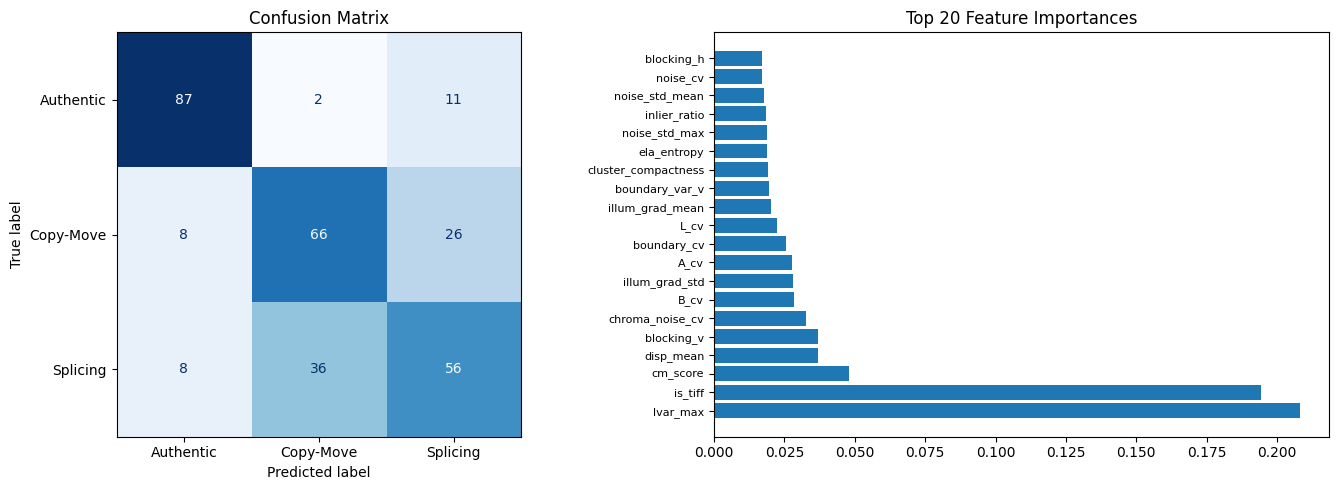

In [14]:
# N=400 per class → ~1200 images total → ~8-10 min on CPU
# Reduce N if needed (N=200 → ~4 min, slightly lower accuracy)
X, y = build_dataset(N=400)
print(f'\nDataset shape: {X.shape}, Class counts: {collections.Counter(y)}')
print('Label map: 0=Authentic, 1=Copy-Move, 2=Splicing\n')

model, scaler = train_and_evaluate(X, y)

In [15]:
CLASS_NAMES = {0: 'Authentic', 1: 'Copy-Move', 2: 'Splicing'}

def predict_image(path, clf, scaler):
    path = Path(path)
    feat = extract_features(path).reshape(1, -1)
    feat = np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0)
    feat_s = scaler.transform(feat)
    pred = clf.predict(feat_s)[0]
    proba = clf.predict_proba(feat_s)[0]
    print(f"\nFile: {path.name}")
    print(f"Prediction: {CLASS_NAMES[pred]}")
    for i, name in CLASS_NAMES.items():
        print(f"  P({name}) = {proba[i]:.3f}")
    return pred, proba

# Example usage:
# predict_image(r"C:\path\to\some_image.jpg", model, scaler)

In [16]:
from sklearn.metrics import accuracy_score
import pandas as pd

def per_class_accuracy(clf, scaler, X, y):
    X_s = scaler.transform(np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0))
    preds = clf.predict(X_s)

    rows = []
    for label, name in CLASS_NAMES.items():
        mask = y == label
        if mask.sum() == 0:
            continue
        acc = accuracy_score(y[mask], preds[mask])
        n = mask.sum()
        correct = (preds[mask] == label).sum()
        # Where did wrong predictions go?
        wrong = preds[mask][preds[mask] != label]
        wrong_counts = collections.Counter(wrong)
        confused_with = ', '.join(
            f"{CLASS_NAMES[k]}({v})" for k, v in wrong_counts.items()
        ) or '—'
        rows.append({
            'Class': name,
            'Total': int(n),
            'Correct': int(correct),
            'Accuracy': f"{acc:.1%}",
            'Confused with': confused_with,
        })

    df = pd.DataFrame(rows)
    print("\n=== Per-Class Accuracy ===")
    print(df.to_string(index=False))
    return df

# Run on test split — re-split the same way as training
X_clean = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
_, X_test_eval, _, y_test_eval = train_test_split(
    X_clean, y, test_size=0.25, stratify=y, random_state=42
)
per_class_accuracy(model, scaler, X_test_eval, y_test_eval)


=== Per-Class Accuracy ===
    Class  Total  Correct Accuracy               Confused with
Authentic    100       87    87.0%  Splicing(11), Copy-Move(2)
Copy-Move    100       66    66.0%  Splicing(26), Authentic(8)
 Splicing    100       56    56.0% Copy-Move(36), Authentic(8)


,Class,Total,Correct,Accuracy,Confused with
0,Authentic,100,87,87.0%,"Splicing(11), Copy-Move(2)"
1,Copy-Move,100,66,66.0%,"Splicing(26), Authentic(8)"
2,Splicing,100,56,56.0%,"Copy-Move(36), Authentic(8)"



=== Copy-Move vs Splicing (hardest sub-problem) ===
              precision    recall  f1-score   support

   Copy-Move       0.89      0.92      0.91       100
    Splicing       0.95      0.89      0.92       100

   micro avg       0.92      0.91      0.91       200
   macro avg       0.92      0.91      0.91       200
weighted avg       0.92      0.91      0.91       200



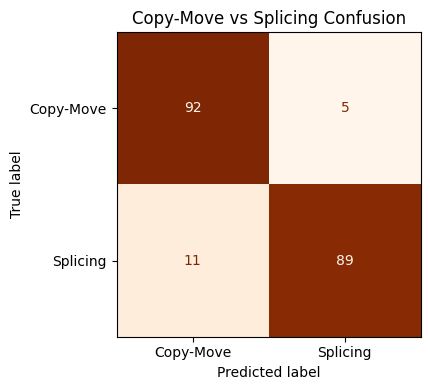

Copy-Move misclassified as Splicing: 5.2%
Splicing misclassified as Copy-Move: 11.0%


In [17]:
def copymove_vs_splicing_analysis(clf, scaler, X, y):
    """
    Focuses exclusively on the hardest sub-problem:
    distinguishing copy-move from splicing (ignoring authentic).
    """
    X_clean = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    mask = (y == 1) | (y == 2)
    X_sub = X_clean[mask]
    y_sub = y[mask]

    _, X_sub_test, _, y_sub_test = train_test_split(
        X_sub, y_sub, test_size=0.25, stratify=y_sub, random_state=42
    )

    X_sub_test_s = scaler.transform(X_sub_test)
    preds = clf.predict(X_sub_test_s)

    print("\n=== Copy-Move vs Splicing (hardest sub-problem) ===")
    print(classification_report(
        y_sub_test, preds,
        labels=[1, 2],
        target_names=['Copy-Move', 'Splicing']
    ))

    cm_sub = confusion_matrix(y_sub_test, preds, labels=[1, 2])
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm_sub, display_labels=['Copy-Move', 'Splicing']).plot(
        ax=ax, cmap='Oranges', colorbar=False
    )
    ax.set_title('Copy-Move vs Splicing Confusion')
    plt.tight_layout()
    plt.show()

    # Compute the specific CM→SP and SP→CM error rates
    if cm_sub[0, 0] + cm_sub[0, 1] > 0:
        cm_as_sp = cm_sub[0, 1] / (cm_sub[0, 0] + cm_sub[0, 1])
        print(f"Copy-Move misclassified as Splicing: {cm_as_sp:.1%}")
    if cm_sub[1, 0] + cm_sub[1, 1] > 0:
        sp_as_cm = cm_sub[1, 0] / (cm_sub[1, 0] + cm_sub[1, 1])
        print(f"Splicing misclassified as Copy-Move: {sp_as_cm:.1%}")

copymove_vs_splicing_analysis(model, scaler, X, y)


=== Feature Discriminability (Cohen's d) — sorted by CM vs Splice ===
Higher = easier to separate that pair with this feature

                     Auth vs CM  Auth vs Splice  CM vs Splice
is_jpeg                   2.225           1.141         0.670
is_tiff                   2.268           1.167         0.670
is_lossless               2.225           1.141         0.670
cm_score                  0.606           0.006         0.606
ela_entropy               1.645           0.848         0.587
block_std                 0.487           0.116         0.540
ela_std                   0.672           0.023         0.538
ela_p95                   0.583           0.009         0.508
ela_mean                  0.520           0.049         0.485
inlier_ratio              0.416           0.005         0.403
lvar_max                  0.044           0.411         0.334
blocking_v                0.125           0.220         0.305
n_inliers                 0.364           0.081         0.296
disp

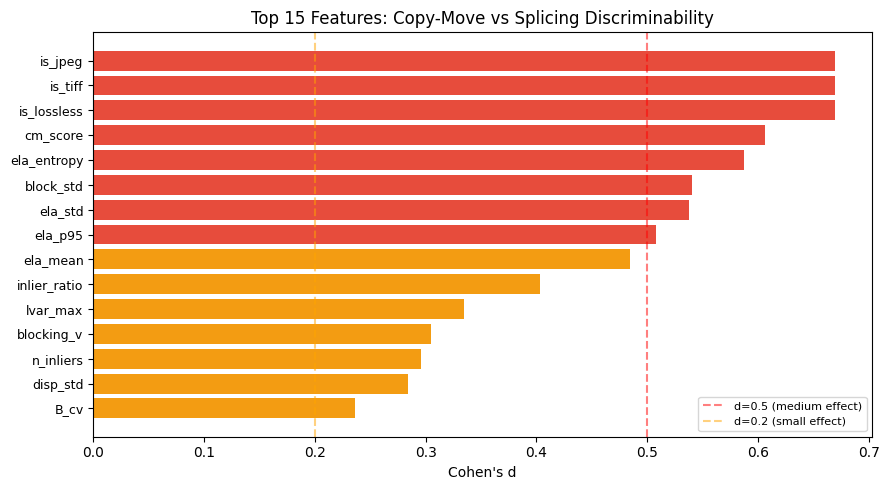

In [18]:
def feature_discriminability(X, y):
    """
    For each feature, shows how well it separates each pair of classes
    using a simple effect size (Cohen's d). Higher = more discriminable.
    Helps you understand WHICH features actually drive copy-move vs splicing separation.
    """
    X_clean = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    pairs = [(0, 1, 'Auth vs CM'), (0, 2, 'Auth vs Splice'), (1, 2, 'CM vs Splice')]

    results = {}
    for la, lb, pair_name in pairs:
        Xa = X_clean[y == la]
        Xb = X_clean[y == lb]
        pooled_std = np.sqrt((Xa.var(axis=0) + Xb.var(axis=0)) / 2 + 1e-8)
        cohens_d = np.abs(Xa.mean(axis=0) - Xb.mean(axis=0)) / pooled_std
        results[pair_name] = cohens_d

    df = pd.DataFrame(results, index=FEATURE_NAMES)
    df = df.sort_values('CM vs Splice', ascending=False)

    print("\n=== Feature Discriminability (Cohen's d) — sorted by CM vs Splice ===")
    print("Higher = easier to separate that pair with this feature\n")
    print(df.round(3).to_string())

    # Plot top 15 features for CM vs Splice
    top15 = df['CM vs Splice'].head(15)
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = ['#e74c3c' if v > 0.5 else '#f39c12' if v > 0.2 else '#95a5a6'
              for v in top15.values]
    ax.barh(range(len(top15)), top15.values[::-1], color=colors[::-1])
    ax.set_yticks(range(len(top15)))
    ax.set_yticklabels(top15.index[::-1], fontsize=9)
    ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='d=0.5 (medium effect)')
    ax.axvline(0.2, color='orange', linestyle='--', alpha=0.5, label='d=0.2 (small effect)')
    ax.set_xlabel("Cohen's d")
    ax.set_title('Top 15 Features: Copy-Move vs Splicing Discriminability')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    return df

disc_df = feature_discriminability(X, y)

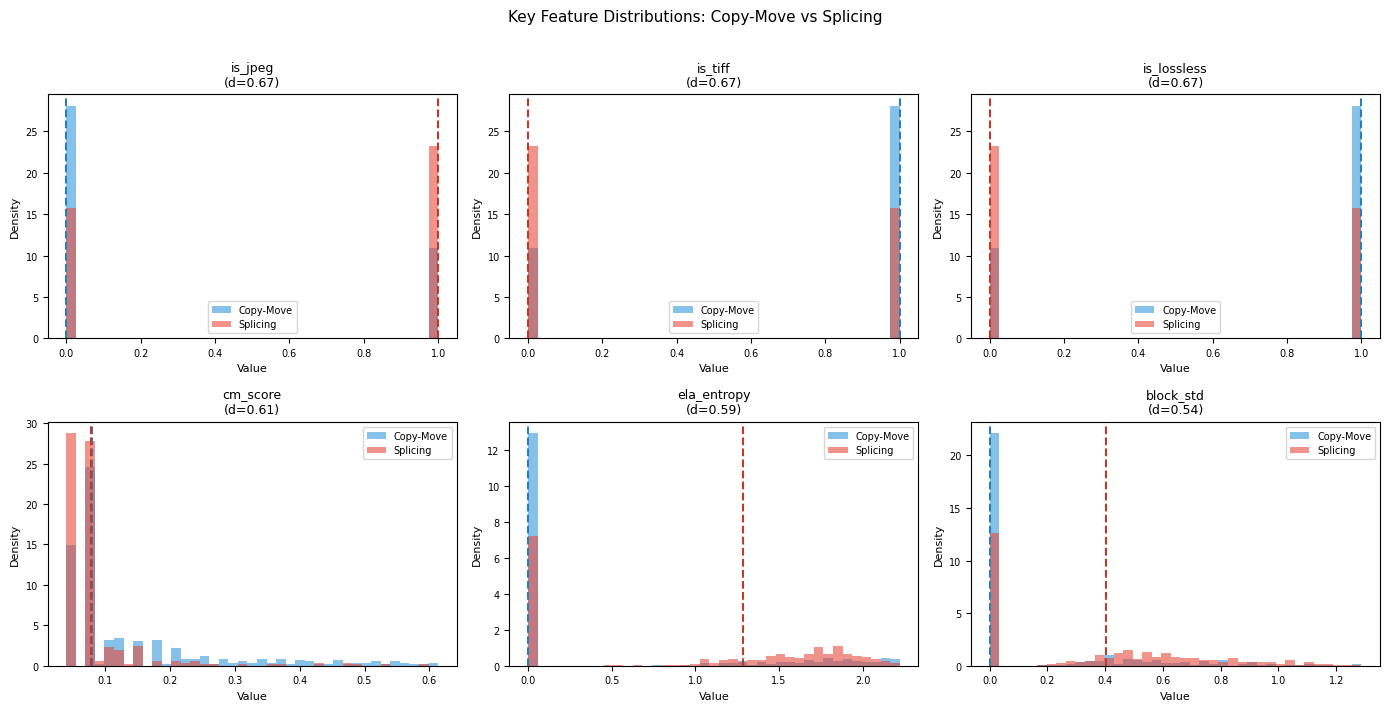

In [19]:
def plot_key_feature_distributions(X, y, top_n=6):
    """
    Plots the actual value distributions of the most discriminative features
    for copy-move vs splicing. Visually shows where/why the classifier struggles.
    """
    X_clean = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    # Pick the top_n features by CM vs Splice Cohen's d
    Xa = X_clean[y == 1]  # copy-move
    Xb = X_clean[y == 2]  # splicing
    pooled_std = np.sqrt((Xa.var(axis=0) + Xb.var(axis=0)) / 2 + 1e-8)
    cohens_d = np.abs(Xa.mean(axis=0) - Xb.mean(axis=0)) / pooled_std
    top_idx = np.argsort(cohens_d)[::-1][:top_n]

    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    axes = axes.flatten()

    for plot_i, feat_i in enumerate(top_idx):
        ax = axes[plot_i]
        vals_cm = Xa[:, feat_i]
        vals_sp = Xb[:, feat_i]

        # Clip extreme outliers for readability
        p2, p98 = np.percentile(np.concatenate([vals_cm, vals_sp]), [2, 98])
        bins = np.linspace(p2, p98, 40)

        ax.hist(vals_cm, bins=bins, alpha=0.6, color='#3498db', label='Copy-Move', density=True)
        ax.hist(vals_sp, bins=bins, alpha=0.6, color='#e74c3c', label='Splicing', density=True)
        ax.axvline(np.median(vals_cm), color='#2980b9', linestyle='--', linewidth=1.5)
        ax.axvline(np.median(vals_sp), color='#c0392b', linestyle='--', linewidth=1.5)
        ax.set_title(f'{FEATURE_NAMES[feat_i]}\n(d={cohens_d[feat_i]:.2f})', fontsize=9)
        ax.legend(fontsize=7)
        ax.set_xlabel('Value', fontsize=8)
        ax.set_ylabel('Density', fontsize=8)
        ax.tick_params(labelsize=7)

    plt.suptitle('Key Feature Distributions: Copy-Move vs Splicing', fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

plot_key_feature_distributions(X, y, top_n=6)

In [20]:
def format_accuracy_breakdown(clf, scaler, X, y):
    """
    Shows accuracy broken down by image format (JPEG vs TIFF/lossless).
    The is_lossless and is_tiff features are at fixed indices in the feature vector.
    This reveals whether the format-aware ELA fix is working.
    """
    X_clean = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    X_s = scaler.transform(X_clean)
    preds = clf.predict(X_s)

    # is_lossless is the 33rd feature (0-indexed: 32)
    is_lossless_col = FEATURE_NAMES.index('is_lossless')
    lossless_mask = X_clean[:, is_lossless_col] > 0.5
    jpeg_mask = ~lossless_mask

    print("\n=== Accuracy by Image Format ===")
    rows = []
    for mask, fmt_name in [(jpeg_mask, 'JPEG'), (lossless_mask, 'TIFF/Lossless')]:
        if mask.sum() == 0:
            continue
        acc = accuracy_score(y[mask], preds[mask])
        bal_acc = balanced_accuracy_score(y[mask], preds[mask])
        class_counts = collections.Counter(y[mask])
        rows.append({
            'Format': fmt_name,
            'N': int(mask.sum()),
            'Authentic': class_counts.get(0, 0),
            'Copy-Move': class_counts.get(1, 0),
            'Splicing': class_counts.get(2, 0),
            'Accuracy': f"{acc:.1%}",
            'Balanced Acc': f"{bal_acc:.1%}",
        })
        print(f"\n{fmt_name} (n={mask.sum()}):")
        print(classification_report(
            y[mask], preds[mask],
            target_names=['Authentic', 'Copy-Move', 'Splicing'],
            zero_division=0
        ))

    df = pd.DataFrame(rows)
    print("\nSummary:")
    print(df.to_string(index=False))
    return df

format_df = format_accuracy_breakdown(model, scaler, X, y)


=== Accuracy by Image Format ===

JPEG (n=748):
              precision    recall  f1-score   support

   Authentic       0.96      0.97      0.96       398
   Copy-Move       0.91      0.79      0.85       112
    Splicing       0.90      0.94      0.92       238

    accuracy                           0.93       748
   macro avg       0.92      0.90      0.91       748
weighted avg       0.93      0.93      0.93       748


TIFF/Lossless (n=452):
              precision    recall  f1-score   support

   Authentic       1.00      1.00      1.00         2
   Copy-Move       0.91      0.96      0.93       288
    Splicing       0.92      0.82      0.87       162

    accuracy                           0.91       452
   macro avg       0.94      0.93      0.93       452
weighted avg       0.91      0.91      0.91       452


Summary:
       Format   N  Authentic  Copy-Move  Splicing Accuracy Balanced Acc
         JPEG 748        398        112       238    93.2%        90.0%
TIFF/Lossle

         EVALUATION SUMMARY
  Total test samples   : 300
  Overall Accuracy     : 69.7%
  Balanced Accuracy    : 69.7%
----------------------------------------------------
  Class            Prec    Rec     F1     N
----------------------------------------------------
  Authentic       84.5%  87.0%  85.7%   100
  Copy-Move       63.5%  66.0%  64.7%   100
  Splicing        60.2%  56.0%  58.0%   100
----------------------------------------------------
  CM vs Splice acc     : 61.0%  ← key metric


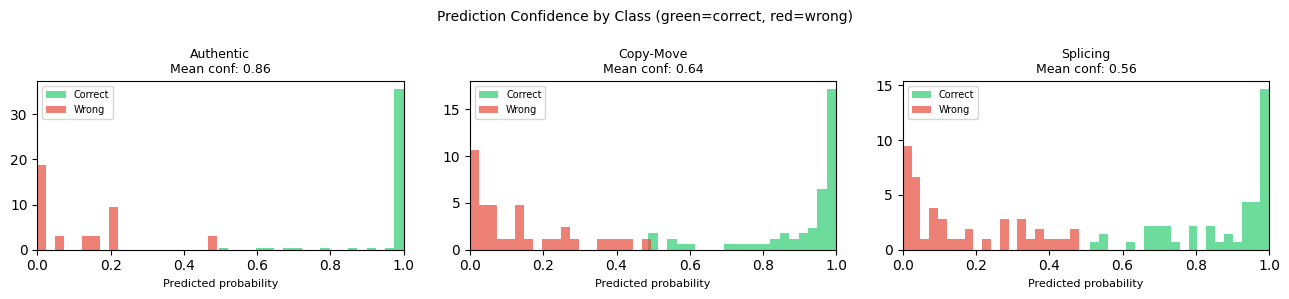

In [21]:
def print_full_summary(clf, scaler, X, y):
    """
    Prints a single clean summary of all key metrics in one place.
    """
    X_clean = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    _, X_test_f, _, y_test_f = train_test_split(
        X_clean, y, test_size=0.25, stratify=y, random_state=42
    )
    X_test_s = scaler.transform(X_test_f)
    preds = clf.predict(X_test_s)
    probas = clf.predict_proba(X_test_s)

    overall_acc = accuracy_score(y_test_f, preds)
    bal_acc = balanced_accuracy_score(y_test_f, preds)

    # Per-class
    report = classification_report(
        y_test_f, preds,
        target_names=['Authentic', 'Copy-Move', 'Splicing'],
        output_dict=True
    )

    print("=" * 52)
    print("         EVALUATION SUMMARY")
    print("=" * 52)
    print(f"  Total test samples   : {len(y_test_f)}")
    print(f"  Overall Accuracy     : {overall_acc:.1%}")
    print(f"  Balanced Accuracy    : {bal_acc:.1%}")
    print("-" * 52)
    print(f"  {'Class':<14} {'Prec':>6} {'Rec':>6} {'F1':>6} {'N':>5}")
    print("-" * 52)
    for name in ['Authentic', 'Copy-Move', 'Splicing']:
        r = report[name]
        print(f"  {name:<14} {r['precision']:>6.1%} {r['recall']:>6.1%} "
              f"{r['f1-score']:>6.1%} {int(r['support']):>5}")
    print("-" * 52)

    # CM vs SP specifically
    mask_cms = (y_test_f == 1) | (y_test_f == 2)
    if mask_cms.sum() > 0:
        preds_cms = preds[mask_cms]
        y_cms = y_test_f[mask_cms]
        cms_acc = accuracy_score(y_cms, preds_cms)
        print(f"  CM vs Splice acc     : {cms_acc:.1%}  ← key metric")
    print("=" * 52)

    # Confidence histogram
    fig, axes = plt.subplots(1, 3, figsize=(13, 3))
    for i, name in enumerate(['Authentic', 'Copy-Move', 'Splicing']):
        mask = y_test_f == i
        if mask.sum() == 0:
            continue
        conf = probas[mask, i]
        correct_mask = preds[mask] == i
        axes[i].hist(conf[correct_mask], bins=20, alpha=0.7,
                     color='#2ecc71', label='Correct', density=True)
        axes[i].hist(conf[~correct_mask], bins=20, alpha=0.7,
                     color='#e74c3c', label='Wrong', density=True)
        axes[i].set_title(f'{name}\nMean conf: {conf.mean():.2f}', fontsize=9)
        axes[i].set_xlabel('Predicted probability', fontsize=8)
        axes[i].legend(fontsize=7)
        axes[i].set_xlim(0, 1)

    plt.suptitle('Prediction Confidence by Class (green=correct, red=wrong)', fontsize=10)
    plt.tight_layout()
    plt.show()

print_full_summary(model, scaler, X, y)